# NfL vs MDS-UPDRS Part III — Within-Subject Longitudinal Analysis
**Pipeline:** SAA+ stratification → z-score normalisation → LMM (random slope) → adjusted LMM

---
## Step 0 — Imports and paths

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats
import warnings, os
warnings.filterwarnings('ignore')

BASE = os.path.join('..', '..', '04_Data', 'Raw')
OUT  = os.path.join('..', '..', '04_Data', 'Results', 'results_nfl_v3')
os.makedirs(OUT, exist_ok=True)


print("Ready.")

Ready.


---
## Step 1 — SAA+ Biological Stratification
We keep only PD patients who tested SAA positive at baseline. This ensures the sample shares the same underlying α-synuclein pathology.

In [2]:
# The SAA export is an xlsx where each cell holds a full CSV row, so it needs re-parsing.
import io, pandas as pd

SAA_PATH = BASE + r'\SAA_Biospecimen_Analysis_Results_21May2026.csv'
raw_xls  = pd.read_excel(SAA_PATH)
col_name = raw_xls.columns[0]
all_lines = col_name + '\n' + '\n'.join(raw_xls.iloc[:, 0].astype(str).tolist())
saa_raw  = pd.read_csv(io.StringIO(all_lines), skipinitialspace=True)

print(f"SAA file loaded: {saa_raw.shape[0]} rows")
print(f"SAA_Status values: {saa_raw['SAA_Status'].value_counts(dropna=False).to_dict()}")

SAA file loaded: 5086 rows
SAA_Status values: {'Positive': 3219, 'Negative': 1735, 'Inconclusive': 132}


In [3]:
bio = pd.read_csv(BASE + r'\Current_Biospecimen_Analysis_Results_21May2026.csv', low_memory=False)
pd_patnos_all = bio[bio['COHORT'] == 'PD']['PATNO'].unique()
print(f"Total PD patients in biospecimen file: {len(pd_patnos_all)}")

# The SAA file and the biospecimen file don't label COHORT=="PD" identically, so
# intersect explicitly instead of trusting the SAA file's own COHORT column.
saa = saa_raw[(saa_raw['COHORT'] == 'PD') & (saa_raw['PATNO'].isin(pd_patnos_all))].copy()

# One SAA status per patient: positive if any visit came back positive
saa_status = saa.groupby('PATNO')['SAA_Status'].apply(
    lambda x: 'Positive' if (x == 'Positive').any() else 'Negative'
).reset_index()
saa_status.columns = ['PATNO', 'SAA_overall']

n_pos = (saa_status['SAA_overall'] == 'Positive').sum()
n_neg = (saa_status['SAA_overall'] == 'Negative').sum()
n_no_data = len(pd_patnos_all) - len(saa_status)

print(f"\nPD patients with SAA data: {len(saa_status)}")
print(f"  SAA+  : {n_pos} ({n_pos/len(saa_status)*100:.1f}%)")
print(f"  SAA-  : {n_neg} ({n_neg/len(saa_status)*100:.1f}%)")
print(f"  No SAA data: {n_no_data}")

Total PD patients in biospecimen file: 1145

PD patients with SAA data: 1051
  SAA+  : 959 (91.2%)
  SAA-  : 92 (8.8%)
  No SAA data: 94


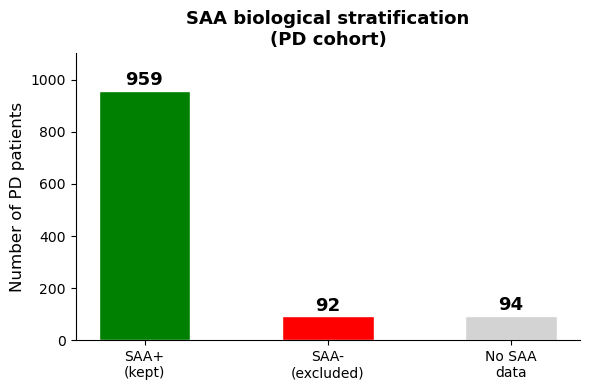

Figure saved.

Proceeding with 959 SAA+ PD patients.


In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = ['SAA+\n(kept)', 'SAA-\n(excluded)', 'No SAA\ndata']
values = [n_pos, n_neg, n_no_data]
colors = ['green', 'red', 'lightgray']

bars = ax.bar(labels, values, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_ylabel('Number of PD patients', fontsize=12)
ax.set_title('SAA biological stratification\n(PD cohort)', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(values) * 1.15)
sns.despine()
plt.tight_layout()
plt.savefig(f'{OUT}/NfL_Fig_SAA_stratification.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

saa_pos_patnos = saa_status[saa_status['SAA_overall'] == 'Positive']['PATNO'].unique()
print(f"\nProceeding with {len(saa_pos_patnos)} SAA+ PD patients.")

---
## Step 2 — Load NfL and MDS-UPDRS, apply filters
- NfL: TESTNAME == 'NfL', values ≤ 150 pg/mL (physiologically plausible range)
- UPDRS: OFF state only (PDSTATE == 'OFF', or unmedicated at baseline)
- Sample: SAA+ PD patients with ≥ 6 matched visits

In [5]:
nfl = bio[(bio['TESTNAME'] == 'NfL') & (bio['PATNO'].isin(saa_pos_patnos))].copy()
nfl = nfl[['PATNO','CLINICAL_EVENT','TESTVALUE','SEX']].rename(
    columns={'TESTVALUE':'NfL','CLINICAL_EVENT':'EVENT_ID'})
nfl['NfL'] = pd.to_numeric(nfl['NfL'], errors='coerce')
nfl = nfl[nfl['NfL'] <= 150].dropna(subset=['NfL'])
nfl = nfl.groupby(['PATNO','EVENT_ID','SEX'], as_index=False)['NfL'].mean()
print(f"NfL records (SAA+, ≤150): {len(nfl)} from {nfl['PATNO'].nunique()} patients")

upd = pd.read_csv(BASE + r'\MDS-UPDRS_Part_III_21May2026.csv', low_memory=False)
upd['NP3TOT'] = pd.to_numeric(upd['NP3TOT'], errors='coerce')
upd['EXAMDT'] = pd.to_datetime(upd['EXAMDT'], format='%m/%Y', errors='coerce')
mask = (upd['PDSTATE'] == 'OFF') | (upd['PDSTATE'].isna() & (upd['PDMEDYN'] != 1))
upd = upd[mask].drop_duplicates(['PATNO','EVENT_ID'])
print(f"UPDRS OFF records: {len(upd)}")

age_df = pd.read_csv(BASE + r'\Age_at_visit_16Jun2026.csv', low_memory=False)

df = nfl.merge(upd[['PATNO','EVENT_ID','EXAMDT','NP3TOT']], on=['PATNO','EVENT_ID'])
df = df.merge(age_df[['PATNO','EVENT_ID','AGE_AT_VISIT']], on=['PATNO','EVENT_ID'], how='left')
df = df.dropna(subset=['NfL','NP3TOT','EXAMDT'])

sex_map = {'Male':1,'Female':0,'male':1,'female':0}
df['SEX_bin'] = df['SEX'].map(sex_map)

vpp = df.groupby('PATNO').size()
dfl = df[df['PATNO'].isin(vpp[vpp >= 3].index)].sort_values(['PATNO','EXAMDT']).copy()
print(f"\nFinal dataset: {dfl['PATNO'].nunique()} patients, {len(dfl)} visits (≥3 visits each)")

NfL records (SAA+, ≤150): 2334 from 524 patients
UPDRS OFF records: 28376

Final dataset: 381 patients, 1636 visits (≥3 visits each)


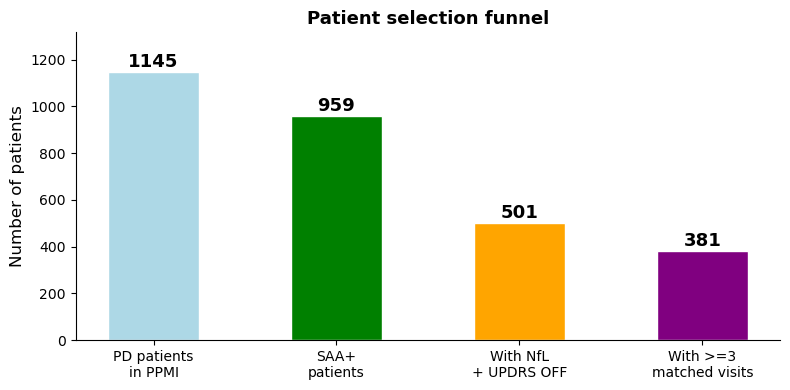

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
steps = ['PD patients\nin PPMI', 'SAA+\npatients', 'With NfL\n+ UPDRS OFF', 'With >=3\nmatched visits']
n_all_pd = len(pd_patnos_all)
n_nfl_upd = df['PATNO'].nunique()
n_final = dfl['PATNO'].nunique()
counts = [n_all_pd, len(saa_pos_patnos), n_nfl_upd, n_final]
colors = ['lightblue', 'green', 'orange', 'purple']

bars = ax.bar(steps, counts, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_ylabel('Number of patients', fontsize=12)
ax.set_title('Patient selection funnel', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(counts) * 1.15)
sns.despine()
plt.tight_layout()
plt.savefig(f'{OUT}/NfL_Fig_funnel.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
csv_path = os.path.join(OUT, 'NfL_filtered_dataset.csv')
dfl.to_csv(csv_path, index=False)
print(f"Filtered dataset saved:")
print(f"  Path    : {csv_path}")
print(f"  Patients: {dfl['PATNO'].nunique()}")
print(f"  Visits  : {len(dfl)}")
print(f"  Columns : {list(dfl.columns)}")

Filtered dataset saved:
  Path    : ..\..\04_Data\Results\results_nfl_v3\NfL_filtered_dataset.csv
  Patients: 381
  Visits  : 1636
  Columns : ['PATNO', 'EVENT_ID', 'SEX', 'NfL', 'EXAMDT', 'NP3TOT', 'AGE_AT_VISIT', 'SEX_bin']


---
## Step 3 — Log2 Transform (no z-score)
NfL values are right-skewed. We apply **log2 transformation** to correct this.
No z-score: keeping NfL in log2 units makes the LMM beta directly interpretable as
**UPDRS points per doubling of NfL** (same units as Mollenhauer 2020), no de-standardizing needed.

**Order:** raw NfL → log2(NfL). UPDRS III is kept in raw points (no transform).

NfL (raw)   : mean=15.07 pg/mL, SD=10.48
NfL (log2)  : mean=3.697, SD=0.755
UPDRS       : mean=25.69 pts,  SD=11.59


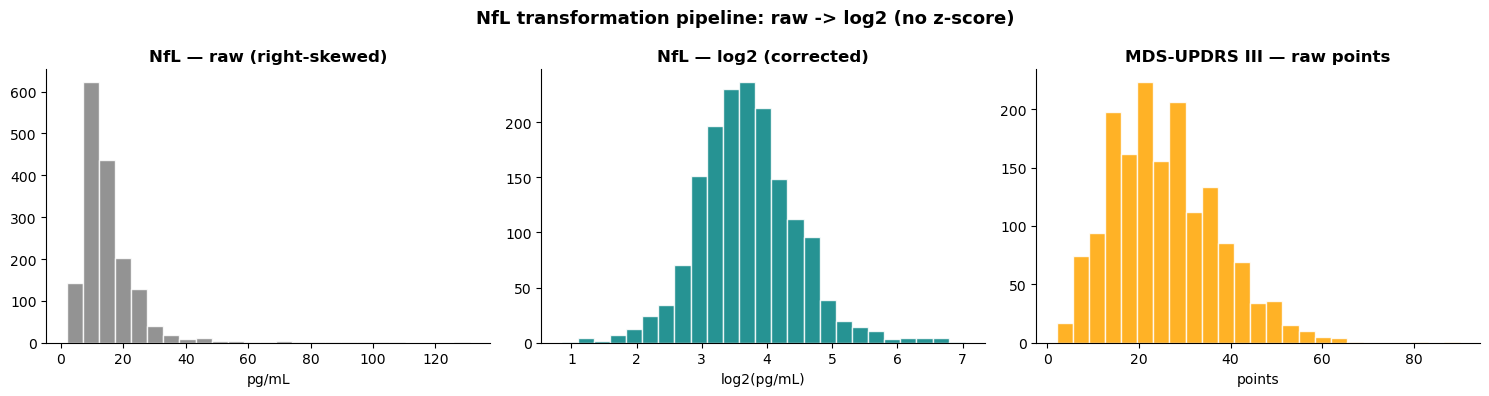

In [8]:
dfl['NfL_log2'] = np.log2(dfl['NfL'])

print(f"NfL (raw)   : mean={dfl['NfL'].mean():.2f} pg/mL, SD={dfl['NfL'].std():.2f}")
print(f"NfL (log2)  : mean={dfl['NfL_log2'].mean():.3f}, SD={dfl['NfL_log2'].std():.3f}")
print(f"UPDRS       : mean={dfl['NP3TOT'].mean():.2f} pts,  SD={dfl['NP3TOT'].std():.2f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(dfl['NfL'],      bins=25, color='gray', edgecolor='white', alpha=0.85)
axes[0].set_title('NfL — raw (right-skewed)', fontweight='bold')
axes[0].set_xlabel('pg/mL')

axes[1].hist(dfl['NfL_log2'], bins=25, color='teal', edgecolor='white', alpha=0.85)
axes[1].set_title('NfL — log2 (corrected)', fontweight='bold')
axes[1].set_xlabel('log2(pg/mL)')

axes[2].hist(dfl['NP3TOT'],  bins=25, color='orange', edgecolor='white', alpha=0.85)
axes[2].set_title('MDS-UPDRS III — raw points', fontweight='bold')
axes[2].set_xlabel('points')

for ax in axes:
    sns.despine(ax=ax)

plt.suptitle('NfL transformation pipeline: raw -> log2 (no z-score)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT}/NfL_Fig_normalisation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 4 — NfL trajectory: PD vs Healthy Controls
Before modelling the NfL-UPDRS relationship, check the raw NfL trajectory:
is NfL really progressing faster in PD than in healthy controls?

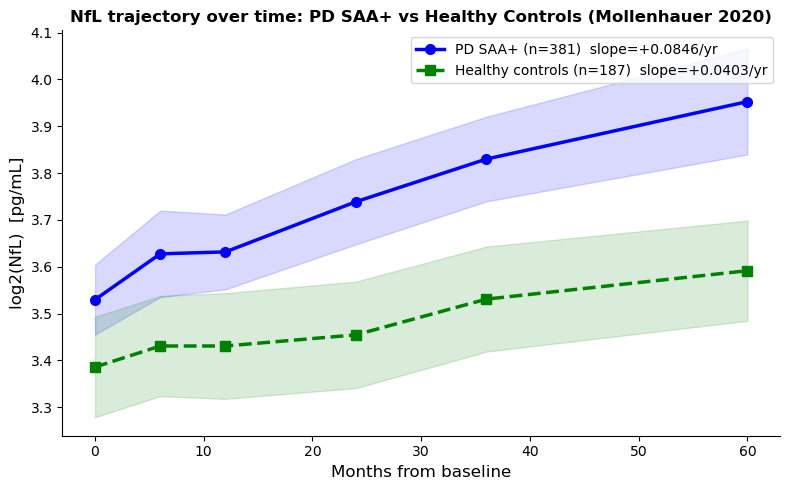

In [9]:
from scipy.stats import sem as scipy_sem, linregress

event_months = {'BL':0,'V02':6,'V04':12,'V06':24,'V08':36,'V10':48,'V12':60}
ctrl_patnos = bio[bio['COHORT'] == 'Control']['PATNO'].unique()
nfl_hc = bio[(bio['TESTNAME'] == 'NfL') & (bio['PATNO'].isin(ctrl_patnos))].copy()
nfl_hc = nfl_hc[['PATNO','CLINICAL_EVENT','TESTVALUE']].rename(
    columns={'TESTVALUE':'NfL','CLINICAL_EVENT':'EVENT_ID'})
nfl_hc['NfL'] = pd.to_numeric(nfl_hc['NfL'], errors='coerce')
nfl_hc = nfl_hc[(nfl_hc['NfL'] <= 150) & (nfl_hc['NfL'] > 0)].dropna(subset=['NfL'])
nfl_hc['NfL_log2'] = np.log2(nfl_hc['NfL'])
nfl_hc['months'] = nfl_hc['EVENT_ID'].map(event_months)
nfl_hc = nfl_hc.dropna(subset=['months'])

nfl_pd = dfl[['PATNO','EVENT_ID','NfL_log2']].copy()
nfl_pd['months'] = nfl_pd['EVENT_ID'].map(event_months)
nfl_pd = nfl_pd.dropna(subset=['months'])

def traj(df):
    out = []
    for m, g in df.groupby('months'):
        v = g['NfL_log2'].dropna().values
        if len(v) < 2: continue
        mu = v.mean(); ci = 1.96 * scipy_sem(v)
        out.append({'months': float(m), 'mean': mu, 'lo': mu-ci, 'hi': mu+ci, 'n': len(v)})
    return pd.DataFrame(out).sort_values('months') if out else pd.DataFrame()

t_pd = traj(nfl_pd)
t_hc = traj(nfl_hc)
sl_pd = linregress(nfl_pd['months'], nfl_pd['NfL_log2'])
sl_hc = linregress(nfl_hc['months'], nfl_hc['NfL_log2'])

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(t_pd['months'], t_pd['lo'], t_pd['hi'], alpha=0.15, color='blue')
ax.plot(t_pd['months'], t_pd['mean'], 'o-', color='blue', lw=2.5, ms=7,
        label=f"PD SAA+ (n={nfl_pd['PATNO'].nunique()})  slope={sl_pd.slope*12:+.4f}/yr")
ax.fill_between(t_hc['months'], t_hc['lo'], t_hc['hi'], alpha=0.15, color='green')
ax.plot(t_hc['months'], t_hc['mean'], 's--', color='green', lw=2.5, ms=7,
        label=f"Healthy controls (n={nfl_hc['PATNO'].nunique()})  slope={sl_hc.slope*12:+.4f}/yr")
ax.set_xlabel('Months from baseline', fontsize=12)
ax.set_ylabel('log2(NfL)  [pg/mL]', fontsize=12)
ax.set_title('NfL trajectory over time: PD SAA+ vs Healthy Controls (Mollenhauer 2020)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f'{OUT}/NfL_Fig_trajectory_PD_vs_HC.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 5 — Linear Mixed Effects Model (adjusted for age + sex)
**Formula:** `NP3TOT ~ NfL_log2 + AGE_AT_VISIT + SEX_bin` with random intercept AND random slope per patient.

Beta is directly interpretable as **UPDRS points per doubling of NfL**.

In [10]:
dfl_m = dfl.dropna(subset=['AGE_AT_VISIT','SEX_bin','NfL_log2','NP3TOT']).copy()
dfl_m['SEX_bin'] = dfl_m['SEX_bin'].astype(int)

n = dfl_m['PATNO'].nunique()
n_f = (dfl_m.drop_duplicates('PATNO')['SEX_bin']==0).sum()
n_m = (dfl_m.drop_duplicates('PATNO')['SEX_bin']==1).sum()
print(f"Patients: {n}  (Female: {n_f}, Male: {n_m})")
print(f"Age: mean={dfl_m['AGE_AT_VISIT'].mean():.1f} y, range=[{dfl_m['AGE_AT_VISIT'].min():.1f}, {dfl_m['AGE_AT_VISIT'].max():.1f}]")

# NP3TOT ~ NfL_log2 + age + sex, random intercept + slope per patient
model = smf.mixedlm('NP3TOT ~ NfL_log2 + AGE_AT_VISIT + SEX_bin',
                    data=dfl_m,
                    groups=dfl_m['PATNO'].astype(str),
                    re_formula='~NfL_log2')
result = model.fit(method='lbfgs')
print(result.summary())

Patients: 381  (Female: 139, Male: 242)
Age: mean=62.6 y, range=[33.7, 89.8]
              Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    NP3TOT    
No. Observations:    1633       Method:                REML      
No. Groups:          381        Scale:                 53.9933   
Min. group size:     2          Log-Likelihood:        -5955.8819
Max. group size:     6          Converged:             Yes       
Mean group size:     4.3                                         
-----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
-----------------------------------------------------------------
Intercept             -7.670    3.426 -2.239 0.025 -14.385 -0.956
NfL_log2               2.831    0.610  4.643 0.000   1.636  4.026
AGE_AT_VISIT           0.354    0.061  5.758 0.000   0.234  0.475
SEX_bin                1.476    1.006  1.467 0.142  -0.495  3.447
Group Var    

In [11]:
beta  = result.params['NfL_log2']
pval  = result.pvalues['NfL_log2']
ci    = result.conf_int()
ci_lo = ci.loc['NfL_log2', 0]
ci_hi = ci.loc['NfL_log2', 1]

print('=' * 65)
print('LMM RESULT — Adjusted for age and sex (random slope per patient)')
print('=' * 65)
print(f'Formula  : NP3TOT ~ NfL_log2 + AGE_AT_VISIT + SEX_bin')
print(f'Patients : {dfl_m["PATNO"].nunique()},  Visits: {len(dfl_m)}')
print(f'UPDRS points per doubling of NfL : {beta:.2f}')
print(f'95% CI       : [{ci_lo:.2f}, {ci_hi:.2f}]')
print(f'p-value      : {pval:.4f}')
print()
if pval < 0.05:
    print(f'-> Significant association after adjustment (p < 0.05)')
else:
    print('-> No significant association after adjustment (p >= 0.05)')
print(f'Age effect: beta={result.params["AGE_AT_VISIT"]:.4f}, p={result.pvalues["AGE_AT_VISIT"]:.4f}')
print('=' * 65)

LMM RESULT — Adjusted for age and sex (random slope per patient)
Formula  : NP3TOT ~ NfL_log2 + AGE_AT_VISIT + SEX_bin
Patients : 381,  Visits: 1633
UPDRS points per doubling of NfL : 2.83
95% CI       : [1.64, 4.03]
p-value      : 0.0000

-> Significant association after adjustment (p < 0.05)
Age effect: beta=0.3540, p=0.0000


---
## Step 6 — LMM scatter plot

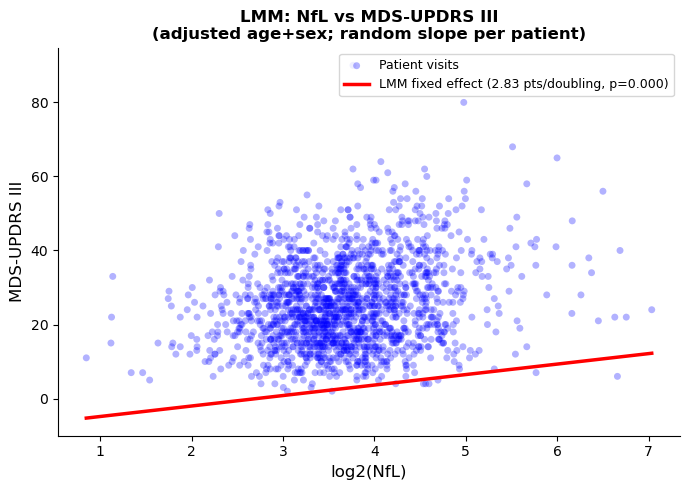

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(dfl_m['NfL_log2'], dfl_m['NP3TOT'], alpha=0.3, s=25,
           color='blue', edgecolor='none', label='Patient visits')
xs = np.linspace(dfl_m['NfL_log2'].min(), dfl_m['NfL_log2'].max(), 100)
ax.plot(xs, result.params['Intercept'] + beta * xs, color='red', linewidth=2.5,
        label=f'LMM fixed effect ({beta:.2f} pts/doubling, p={pval:.3f})')
ax.set_xlabel('log2(NfL)', fontsize=12)
ax.set_ylabel('MDS-UPDRS III', fontsize=12)
ax.set_title('LMM: NfL vs MDS-UPDRS III\n(adjusted age+sex; random slope per patient)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f'{OUT}/NfL_Fig_LMM_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 7 — Quantifying age and sex: how relevant are they?
Two checks:
1. Effect size in real units: UPDRS points per year of age, and points difference male vs female.
2. Likelihood ratio test (LRT): compare model WITH vs WITHOUT age+sex to see how much they
   jointly improve the fit (chi-square test on -2*log-likelihood difference).

Note: this LRT only tells us age+sex improve fit *within this PD-only model*. It does not by
itself prove an age x disease interaction -- that would require fitting age in healthy controls
as well and comparing (done separately, see notebook discussion).

In [13]:
beta_age = result.params['AGE_AT_VISIT']
p_age    = result.pvalues['AGE_AT_VISIT']
ci_age   = result.conf_int().loc['AGE_AT_VISIT']

beta_sex = result.params['SEX_bin']
p_sex    = result.pvalues['SEX_bin']
ci_sex   = result.conf_int().loc['SEX_bin']

print('AGE  : {:.3f} UPDRS points per year, 95% CI=[{:.3f}, {:.3f}], p={:.4f}'.format(
    beta_age, ci_age[0], ci_age[1], p_age))
print('SEX  : {:.3f} UPDRS points (male vs female), 95% CI=[{:.3f}, {:.3f}], p={:.4f}'.format(
    beta_sex, ci_sex[0], ci_sex[1], p_sex))
print()
print(f'-> Over a 10-year age difference: {beta_age*10:.1f} UPDRS points difference')
print()

# Likelihood-ratio test: model with vs without age+sex
model_no_covar = smf.mixedlm('NP3TOT ~ NfL_log2',
                              data=dfl_m, groups=dfl_m['PATNO'].astype(str),
                              re_formula='~NfL_log2')
result_no_covar = model_no_covar.fit(method='lbfgs')

llf_full = result.llf
llf_reduced = result_no_covar.llf
lr_stat = 2 * (llf_full - llf_reduced)
df_diff = 2  # age + sex = 2 extra parameters
lr_pvalue = stats.chi2.sf(lr_stat, df_diff)

print(f'Log-likelihood WITH age+sex    : {llf_full:.2f}')
print(f'Log-likelihood WITHOUT age+sex : {llf_reduced:.2f}')
print(f'LR statistic (chi2, df=2)      : {lr_stat:.2f}')
print(f'LR test p-value                : {lr_pvalue:.6f}')
print()
if lr_pvalue < 0.05:
    print('-> Age + sex jointly improve the model fit significantly (LR test p<0.05).')
    print('   This justifies keeping them as covariates, even though SEX alone was not')
    print('   individually significant.')
else:
    print('-> Age + sex do NOT significantly improve the model fit')

AGE  : 0.354 UPDRS points per year, 95% CI=[0.234, 0.475], p=0.0000
SEX  : 1.476 UPDRS points (male vs female), 95% CI=[-0.495, 3.447], p=0.1423

-> Over a 10-year age difference: 3.5 UPDRS points difference

Log-likelihood WITH age+sex    : -5955.88
Log-likelihood WITHOUT age+sex : -5975.82
LR statistic (chi2, df=2)      : 39.87
LR test p-value                : 0.000000

-> Age + sex jointly improve the model fit significantly (LR test p<0.05).
   This justifies keeping them as covariates, even though SEX alone was not
   individually significant.


---
## Step 8 — Mundlak decomposition: within vs between components of NfL
A single ("conflated") NfL coefficient mixes two different signals:
- **within** (intra-patient): does this patient's own NfL fluctuation, relative to their own mean
  across observed visits, track their own UPDRS?
- **between** (inter-patient): do patients with a higher patient-specific mean NfL tend to have
  higher UPDRS than other patients?
- **γ contextual** (Hausman-type test): is the difference between within and between estimates
  statistically distinguishable?

Note: `NfL_log2_mean` is the patient-specific mean NfL across their *observed* follow-up visits —
not necessarily a true baseline or a fixed biological trait.

In [14]:
# UPDRS total = NP1RTOT + NP1PTOT + NP2PTOT + NP3TOT + NP4TOT
p1a = pd.read_csv(BASE + r'\MDS-UPDRS_Part_I_22Jun2026.csv', low_memory=False)[['PATNO','EVENT_ID','NP1RTOT']]
p1b = pd.read_csv(BASE + r'\MDS-UPDRS_Part_I_Patient_Questionnaire_22Jun2026.csv', low_memory=False)[['PATNO','EVENT_ID','NP1PTOT']]
_p2 = pd.read_excel(BASE + r'\MDS_UPDRS_Part_II__Patient_Questionnaire_21May2026.csv')
p2  = pd.read_csv(io.StringIO(_p2.columns[0] + '\n' + '\n'.join(_p2.iloc[:,0].astype(str))))[['PATNO','EVENT_ID','NP2PTOT']]
p4  = pd.read_csv(BASE + r'\MDS-UPDRS_Part_IV__Motor_Complications_22Jun2026.csv', low_memory=False)[['PATNO','EVENT_ID','NP4TOT']]

tot = (dfl[['PATNO','EVENT_ID','NP3TOT']]
       .merge(p1a, on=['PATNO','EVENT_ID'], how='left')
       .merge(p1b, on=['PATNO','EVENT_ID'], how='left')
       .merge(p2,  on=['PATNO','EVENT_ID'], how='left')
       .merge(p4,  on=['PATNO','EVENT_ID'], how='left'))
tot['UPDRS_TOTAL'] = tot[['NP1RTOT','NP1PTOT','NP2PTOT','NP3TOT','NP4TOT']].sum(axis=1, min_count=5)
base_m = dfl.merge(tot[['PATNO','EVENT_ID','UPDRS_TOTAL']], on=['PATNO','EVENT_ID'], how='left')

MIN_VISITS = 3

def add_mundlak(d, var='NfL_log2'):
    g = d.groupby('PATNO')[var]
    d = d.copy()
    d[var + '_mean'] = g.transform('mean')      # between-patient component
    d[var + '_cwc']  = d[var] - d[var + '_mean'] # within-patient component
    return d

def fit_outcome(data, outcome):
    d = data.dropna(subset=[outcome,'NfL_log2','AGE_AT_VISIT','SEX_bin']).copy()
    vc = d.groupby('PATNO').size()
    d = d[d['PATNO'].isin(vc[vc >= MIN_VISITS].index)].copy()
    d = add_mundlak(d, 'NfL_log2')
    n_pat, n_vis = d['PATNO'].nunique(), len(d)
    rows = []
    def grab(res, term, label, model):
        ci = res.conf_int()
        rows.append([outcome, model, label, res.params[term],
                     ci.loc[term,0], ci.loc[term,1], res.pvalues[term], n_pat, n_vis])
    r1 = smf.mixedlm(f'{outcome} ~ NfL_log2 + AGE_AT_VISIT + SEX_bin',
                     d, groups=d['PATNO'].astype(str), re_formula='~NfL_log2').fit(method='lbfgs')
    grab(r1, 'NfL_log2', 'NfL (β conflated)', 'Conflated')
    r2 = smf.mixedlm(f'{outcome} ~ NfL_log2_cwc + NfL_log2_mean + AGE_AT_VISIT + SEX_bin',
                     d, groups=d['PATNO'].astype(str), re_formula='~NfL_log2_cwc').fit(method='lbfgs')
    grab(r2, 'NfL_log2_cwc',  'NfL within (intra-paciente)',  'Mundlak')
    grab(r2, 'NfL_log2_mean', 'NfL between (entre pacientes)', 'Mundlak')
    r3 = smf.mixedlm(f'{outcome} ~ NfL_log2 + NfL_log2_mean + AGE_AT_VISIT + SEX_bin',
                     d, groups=d['PATNO'].astype(str), re_formula='~NfL_log2').fit(method='lbfgs')
    grab(r3, 'NfL_log2_mean', 'γ contextual (between - within)', 'Hausman')
    return rows

results  = fit_outcome(base_m, 'UPDRS_TOTAL')
results += fit_outcome(base_m, 'NP3TOT')

res = pd.DataFrame(results, columns=['Outcome','Model','Term','beta','CI_low','CI_high','p','n_pat','n_vis'])
res[['beta','CI_low','CI_high']] = res[['beta','CI_low','CI_high']].round(3)
res['p'] = res['p'].round(4)
res['sig'] = np.where(res['p'] < 0.05, '*', '')
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', None)
print(f'Patients with >= {MIN_VISITS} usable visits (NfL log2 -> UPDRS points per doubling)\n')
print(res.to_string(index=False))
print()
print('Caution in interpretation:')
print('- The within estimate is the component most consistent with this data: NfL fluctuation')
print('  within the same patient tracks their own UPDRS, in both outcomes.')
print('- The between estimate is small and not statistically supported here (CI crosses 0).')
print('  This does NOT prove there is no between-patient relationship -- only that this sample')
print('  does not provide clear support for one.')
print('- The significant gamma (Hausman) confirms within and between are statistically distinct,')
print('  which is why collapsing them into a single conflated coefficient is misleading here.')

Patients with >= 3 usable visits (NfL log2 -> UPDRS points per doubling)

    Outcome     Model                            Term    beta  CI_low  CI_high      p  n_pat  n_vis sig
UPDRS_TOTAL Conflated               NfL (β conflated)   6.179   3.030    9.328 0.0001    212    740   *
UPDRS_TOTAL   Mundlak     NfL within (intra-paciente)  10.171   6.476   13.867 0.0000    212    740   *
UPDRS_TOTAL   Mundlak   NfL between (entre pacientes)   2.458  -1.694    6.610 0.2459    212    740    
UPDRS_TOTAL   Hausman γ contextual (between - within) -10.033 -14.890   -5.176 0.0001    212    740   *
     NP3TOT Conflated               NfL (β conflated)   2.824   1.625    4.023 0.0000    379   1629   *
     NP3TOT   Mundlak     NfL within (intra-paciente)   5.107   3.631    6.582 0.0000    379   1629   *
     NP3TOT   Mundlak   NfL between (entre pacientes)  -1.346  -3.228    0.535 0.1608    379   1629    
     NP3TOT   Hausman γ contextual (between - within)  -7.103  -9.248   -4.958 0.0000    379  

---
## Step 9 — Forest plot: within / between / conflated
Visual summary of the decomposition above. The within estimate (green) is the component
most consistent with the data; the between estimate (red) has wide, zero-crossing intervals
in this sample.

Guardado: ..\..\04_Data\Results\results_nfl_v3/NfL_Fig_forest_within_between.png


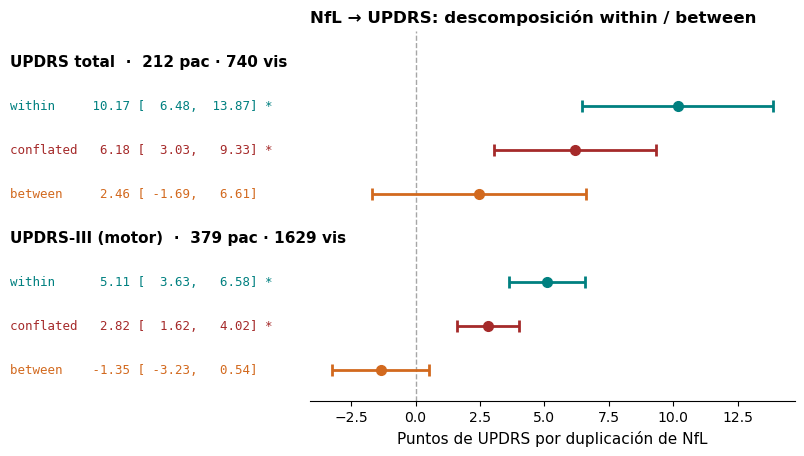

In [15]:
CLR = {'within': 'teal', 'conflated': 'brown', 'between': 'chocolate'}
OUT_LABEL = {'UPDRS_TOTAL':'UPDRS total', 'NP3TOT':'UPDRS-III (motor)'}

def _cat(term):
    if 'within'    in term: return 'within'
    if 'conflated' in term: return 'conflated'
    if 'between'   in term and 'γ' not in term: return 'between'
    return None

def forest_plot(res, outcomes=('UPDRS_TOTAL','NP3TOT'), save=None,
                xlabel='Puntos de UPDRS por duplicación de NfL'):
    order = ['within','conflated','between']
    rows = []
    for oc in outcomes:
        sub = res[res['Outcome'] == oc]
        if len(sub) == 0: continue
        rows.append(('header', f"{OUT_LABEL.get(oc, oc)}  ·  "
                                f"{sub['n_pat'].iloc[0]} pac · {sub['n_vis'].iloc[0]} vis", None))
        for c in order:
            r = sub[sub['Term'].apply(_cat) == c]
            if len(r): rows.append(('data', c, r.iloc[0]))

    n = len(rows)
    fig, ax = plt.subplots(figsize=(8.5, 0.5*n + 1))
    ypos = list(range(n, 0, -1))

    for y, (kind, label, r) in zip(ypos, rows):
        if kind == 'header':
            ax.text(-0.62, y, label, transform=ax.get_yaxis_transform(),
                    ha='left', va='center', fontsize=11, fontweight='bold')
            continue
        c = label
        beta_, lo, hi, p = r['beta'], r['CI_low'], r['CI_high'], r['p']
        sig = '*' if p < 0.05 else ''
        ax.errorbar(beta_, y, xerr=[[beta_-lo], [hi-beta_]], fmt='o', ms=7,
                    color=CLR[c], ecolor=CLR[c], elinewidth=2,
                    capsize=4, capthick=2, zorder=3)
        ax.text(-0.62, y, f'{c:<9} {beta_:6.2f} [{lo:6.2f}, {hi:6.2f}] {sig}',
                transform=ax.get_yaxis_transform(), ha='left', va='center',
                fontsize=9, family='monospace', color=CLR[c])

    ax.axvline(0, color='grey', lw=1, ls='--', alpha=0.7, zorder=1)
    ax.set_yticks([])
    ax.set_ylim(0.3, n + 0.7)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_title('NfL → UPDRS: descomposición within / between',
                 fontsize=12, fontweight='bold', loc='left')
    for s in ['top','right','left']:
        ax.spines[s].set_visible(False)
    plt.subplots_adjust(left=0.40, right=0.97, top=0.90, bottom=0.16)
    if save:
        plt.savefig(save, dpi=150, bbox_inches='tight')
        print('Guardado:', save)
    plt.show()

forest_plot(res, save=f'{OUT}/NfL_Fig_forest_within_between.png')